QUESTION 1: MODEL SCORES
Logistic Regression  Test Accuracy: 0.9622
SVM                  Test Accuracy: 0.9911
Random Forest        Test Accuracy: 0.9600
Decision Tree        Test Accuracy: 0.8244

QUESTION 1: CROSS-VALIDATION SCORES (5-Fold)
Logistic Regression  CV Scores: [0.97777778 0.97407407 0.94795539 0.9739777  0.95910781]
                     Mean: 0.9666 (+/- 0.0226)

SVM                  CV Scores: [0.99259259 0.97777778 0.98884758 0.98884758 0.98513011]
                     Mean: 0.9866 (+/- 0.0100)

Random Forest        CV Scores: [0.97407407 0.97037037 0.97026022 0.98141264 0.97769517]
                     Mean: 0.9748 (+/- 0.0086)

Decision Tree        CV Scores: [0.86296296 0.87407407 0.86245353 0.84758364 0.78066914]
                     Mean: 0.8455 (+/- 0.0670)



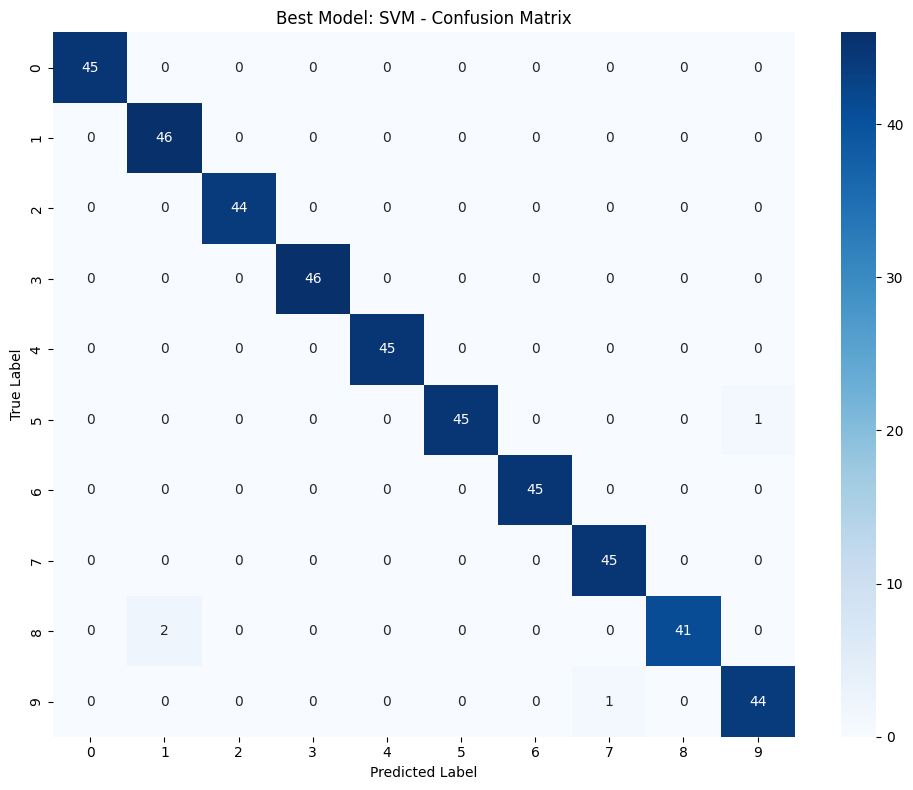

In [1]:
# ==============================================
# RESIT 2024 - QUESTION 1 & 2
# Digits Dataset - Supervised Learning & K-Means
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split (using default 75/25 as per instruction)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ==============================================
# QUESTION 1: Model Scores (10 Marks)
# ==============================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

print("="*60)
print("QUESTION 1: MODEL SCORES")
print("="*60)
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name:20s} Test Accuracy: {score:.4f}")

# 2. Cross-validation with 5 folds (10 Marks)
print("\n" + "="*60)
print("QUESTION 1: CROSS-VALIDATION SCORES (5-Fold)")
print("="*60)
best_model = None
best_mean_score = 0
best_name = ""

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = cv_scores.mean()
    print(f"{name:20s} CV Scores: {cv_scores}")
    print(f"{'':20s} Mean: {mean_score:.4f} (+/- {cv_scores.std()*2:.4f})\n")
    
    if mean_score > best_mean_score:
        best_mean_score = mean_score
        best_model = model
        best_name = name

# 3. Plot confusion matrix for best model (10 Marks)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.title(f'Best Model: {best_name} - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

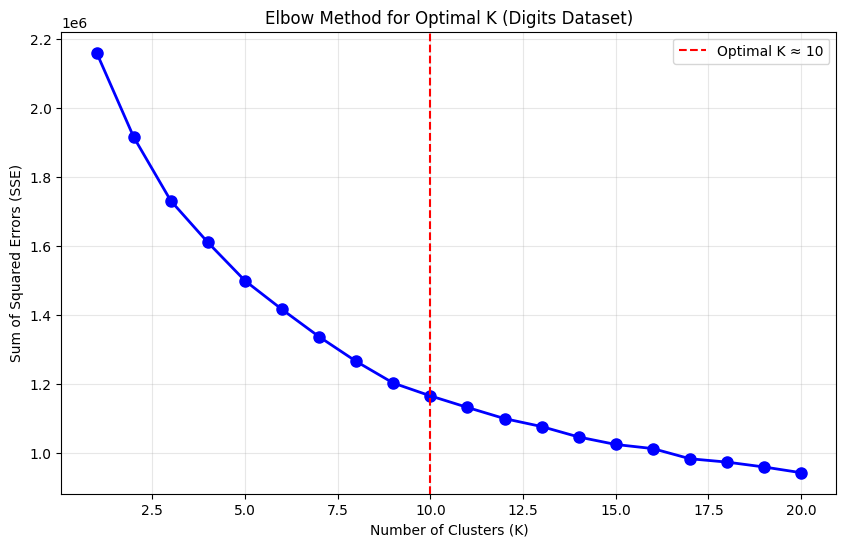

Optimal K ≈ 10 (matches number of digit classes)


In [2]:
# ==============================================
# RESIT 2024 - QUESTION 2
# K-Means Clustering - Elbow Method (10 Marks)
# ==============================================

from sklearn.cluster import KMeans

# Use digits dataset (X)
sse = []  # Sum of Squared Errors

# Try K from 1 to 20
k_range = range(1, 21)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal K (Digits Dataset)')
plt.axvline(x=10, color='red', linestyle='--', label='Optimal K ≈ 10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# The optimal K is where the elbow occurs
# For digits dataset (10 classes), optimal K ≈ 10
print("Optimal K ≈ 10 (matches number of digit classes)")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)

MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 165ms/step - accuracy: 0.3179 - loss: 1.8266 - val_accuracy: 0.4811 - val_loss: 1.4027
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 166ms/step - accuracy: 0.5096 - loss: 1.3507 - val_accuracy: 0.5705 - val_loss: 1.1840
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 172ms/step - accuracy: 0.5836 - loss: 1.1627 - val_accuracy: 0.6411 - val_loss: 1.0235
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 310ms/step - accuracy: 0.6256 - loss: 1.0598 - val_accuracy: 0.6651 - val_loss: 0.9306
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.6507 - loss: 0.9860 - val_accuracy: 0.6991 - val_loss: 0.8531

Test Accuracy: 0.6929
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


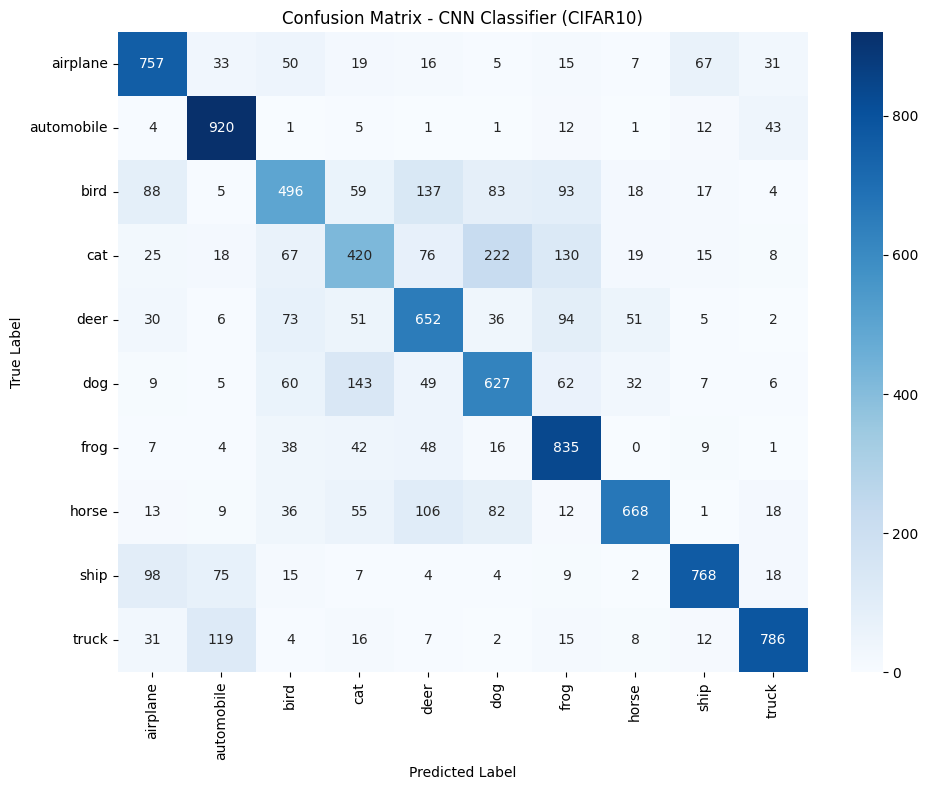

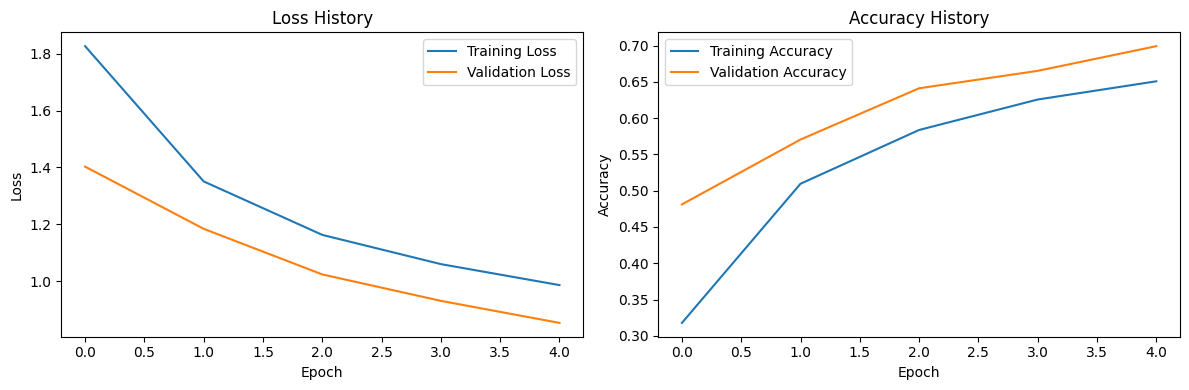

In [4]:
# ==============================================
# RESIT 2024 - QUESTION 3
# CIFAR10 with CNN (30 Marks)
# ==============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load CIFAR10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# ==============================================
# Build CNN: 3 stacks of (Conv + ReLU + Pooling)
# + Fully Connected Output Layer
# ==============================================

model = keras.Sequential([
    # Stack 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                  input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Stack 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Stack 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),
    
    # Fully connected output layer
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 1. Compile and train it (10 Marks)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Generate summary of the network (10 Marks)
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
model.summary()

# Train
history = model.fit(
    X_train, y_train,
    epochs=5, # Can change later
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# 3. Plot confusion matrix (10 Marks)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - CNN Classifier (CIFAR10)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy History')

plt.tight_layout()
plt.show()